# 03 Validation
## 검증


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

def load_table(name):
    path = TABLE_DIR / name
    if not path.exists() and Path(name).suffix == "":
        path = TABLE_DIR / f"{name}.csv"
    return pd.read_csv(path)

def save_figure(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path

def show_saved_figure(name):
    path = save_figure(name)
    plt.close()
    display(Image(filename=str(path)))

def pct(x, digits=2):
    return (x.astype(float) * 100).round(digits)


## Decile Test
### 분위 검증


,risk_decile_label,customers,observed_defaults,avg_risk_score,default_rate_pct,score_gap_vs_next
0,D1\nHighest,45892,44326,0.964196,96.59,0.159420
1,D2,45891,36850,0.804775,80.30,0.279284
2,D3,45891,23940,0.525491,52.17,0.309929
3,D4,45892,10123,0.215562,22.06,0.161213
4,D5,45891,2549,0.054349,5.55,0.039795
5,D6,45891,662,0.014554,1.44,0.009218
6,D7,45892,219,0.005337,0.48,0.002827
7,D8,45891,96,0.002509,0.21,0.001134
8,D9,45891,45,0.001375,0.10,0.000642
9,D10\nLowest,45891,18,0.000733,0.04,NaN


,check,value
0,score_monotonic,True
1,default_rate_monotonic,True
2,D1_default_rate,96.59
3,D10_default_rate,0.04


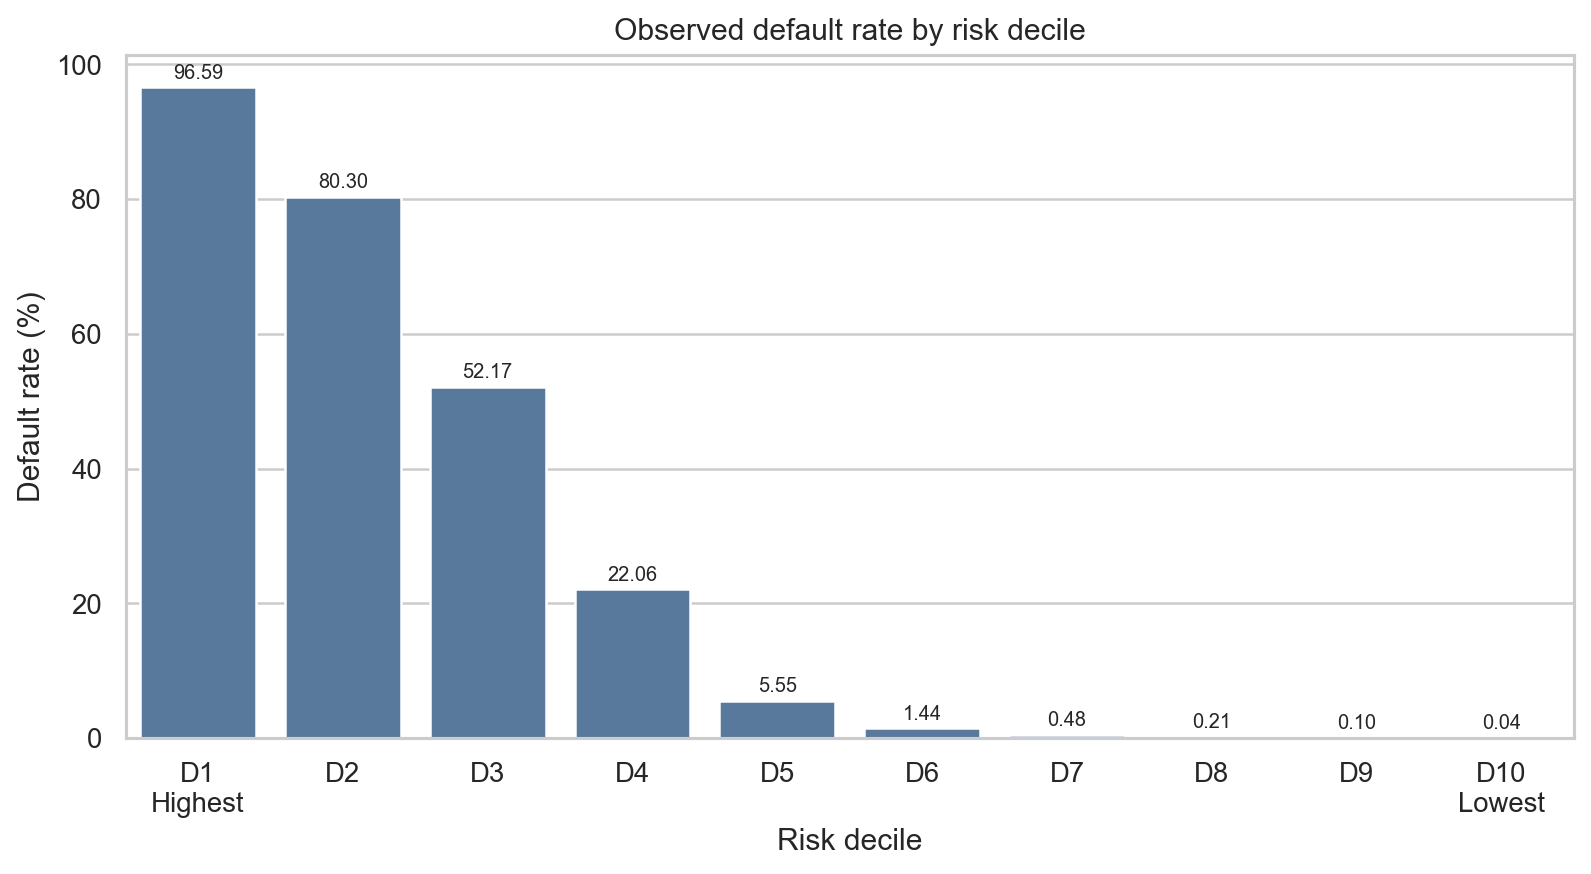

In [2]:
decile = load_table("risk_decile_summary.csv")
decile["default_rate_pct"] = pct(decile["observed_default_rate"])
decile["score_gap_vs_next"] = decile["avg_risk_score"].diff(-1)
decile["is_monotonic_score"] = decile["avg_risk_score"].diff().fillna(0).le(0)
decile["is_monotonic_default_rate"] = decile["observed_default_rate"].diff().fillna(0).le(0)

display(decile[["risk_decile_label", "customers", "observed_defaults", "avg_risk_score", "default_rate_pct", "score_gap_vs_next"]])
display(
    pd.DataFrame(
        {
            "check": ["score_monotonic", "default_rate_monotonic", "D1_default_rate", "D10_default_rate"],
            "value": [
                bool(decile["is_monotonic_score"].all()),
                bool(decile["is_monotonic_default_rate"].all()),
                round(decile.loc[decile["risk_decile"].eq(1), "observed_default_rate"].iloc[0] * 100, 2),
                round(decile.loc[decile["risk_decile"].eq(10), "observed_default_rate"].iloc[0] * 100, 2),
            ],
        }
    )
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=decile, x="risk_decile_label", y="default_rate_pct", color="#4C78A8", ax=ax)
ax.set_title("Observed default rate by risk decile")
ax.set_xlabel("Risk decile")
ax.set_ylabel("Default rate (%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
show_saved_figure("risk_bucket_decile_validation.png")


D1 96.59%, D10 0.04%. 점수 순서가 default concentration을 만든다.


## Band Test
### 밴드 검증


,risk_band,customer_count,default_count,default_rate_pct,capture_share_pct,avg_risk_score,min_risk_score,max_risk_score
0,Critical,4589,4588,99.98,3.86,0.997642,0.996460,0.999092
1,High Risk,18356,18153,98.89,15.28,0.986248,0.970803,0.996460
2,Watchlist,22946,21584,94.06,18.16,0.939868,0.904279,0.970801
3,Standard,413022,74503,18.04,62.70,0.180522,0.000249,0.904275


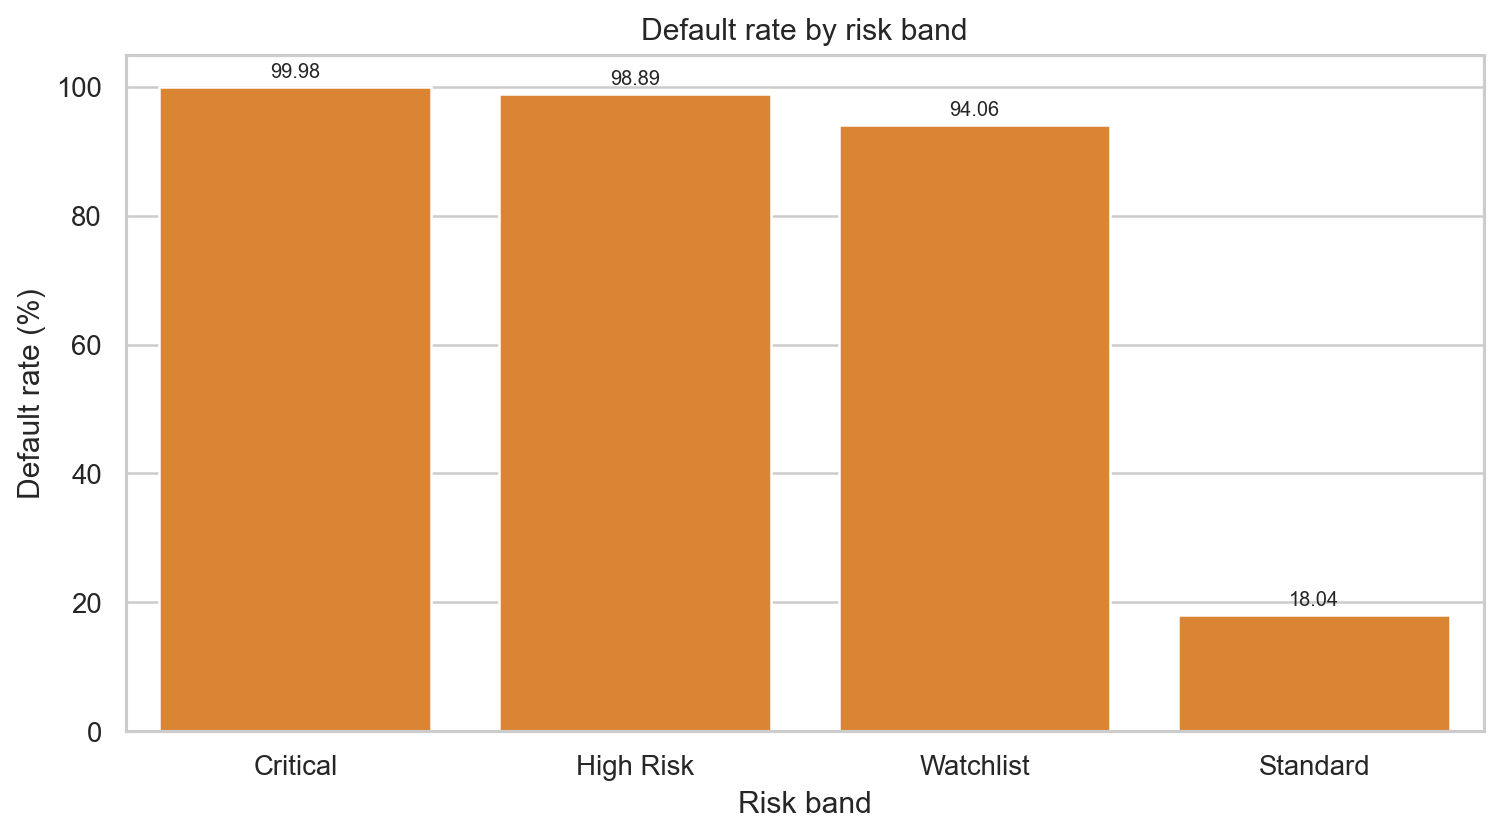

In [3]:
band = load_table("monitoring_bucket_summary").sort_values("avg_risk_score", ascending=False)
band["default_rate_pct"] = pct(band["default_rate"])
band["capture_share_pct"] = pct(band["capture_share"])
display(
    band[
        [
            "risk_band",
            "customer_count",
            "default_count",
            "default_rate_pct",
            "capture_share_pct",
            "avg_risk_score",
            "min_risk_score",
            "max_risk_score",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.barplot(data=band, x="risk_band", y="default_rate_pct", color="#F58518", ax=ax)
ax.set_title("Default rate by risk band")
ax.set_xlabel("Risk band")
ax.set_ylabel("Default rate (%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
show_saved_figure("default_rate_by_risk_band.png")


Critical과 High가 운영 review 대상의 중심이다.


## Capture Curve
### 포착률 곡선


,review_scope,review_count,captured_defaults,capture_rate,default_rate_among_reviewed,capture_rate_pct,default_rate_among_reviewed_pct
0,10,45891,44325,0.373018,0.965876,37.30,96.59
1,20,91783,81176,0.683139,0.884434,68.31,88.44
2,30,137674,105116,0.884606,0.763514,88.46,76.35
3,40,183565,115239,0.969797,0.627783,96.98,62.78
4,50,229456,117788,0.991248,0.513336,99.12,51.33
5,60,275348,118450,0.996819,0.430183,99.68,43.02
6,70,321239,118669,0.998662,0.369410,99.87,36.94
7,80,367130,118765,0.999470,0.323496,99.95,32.35
8,90,413022,118810,0.999849,0.287660,99.98,28.77
9,100,458913,118828,1.000000,0.258934,100.00,25.89


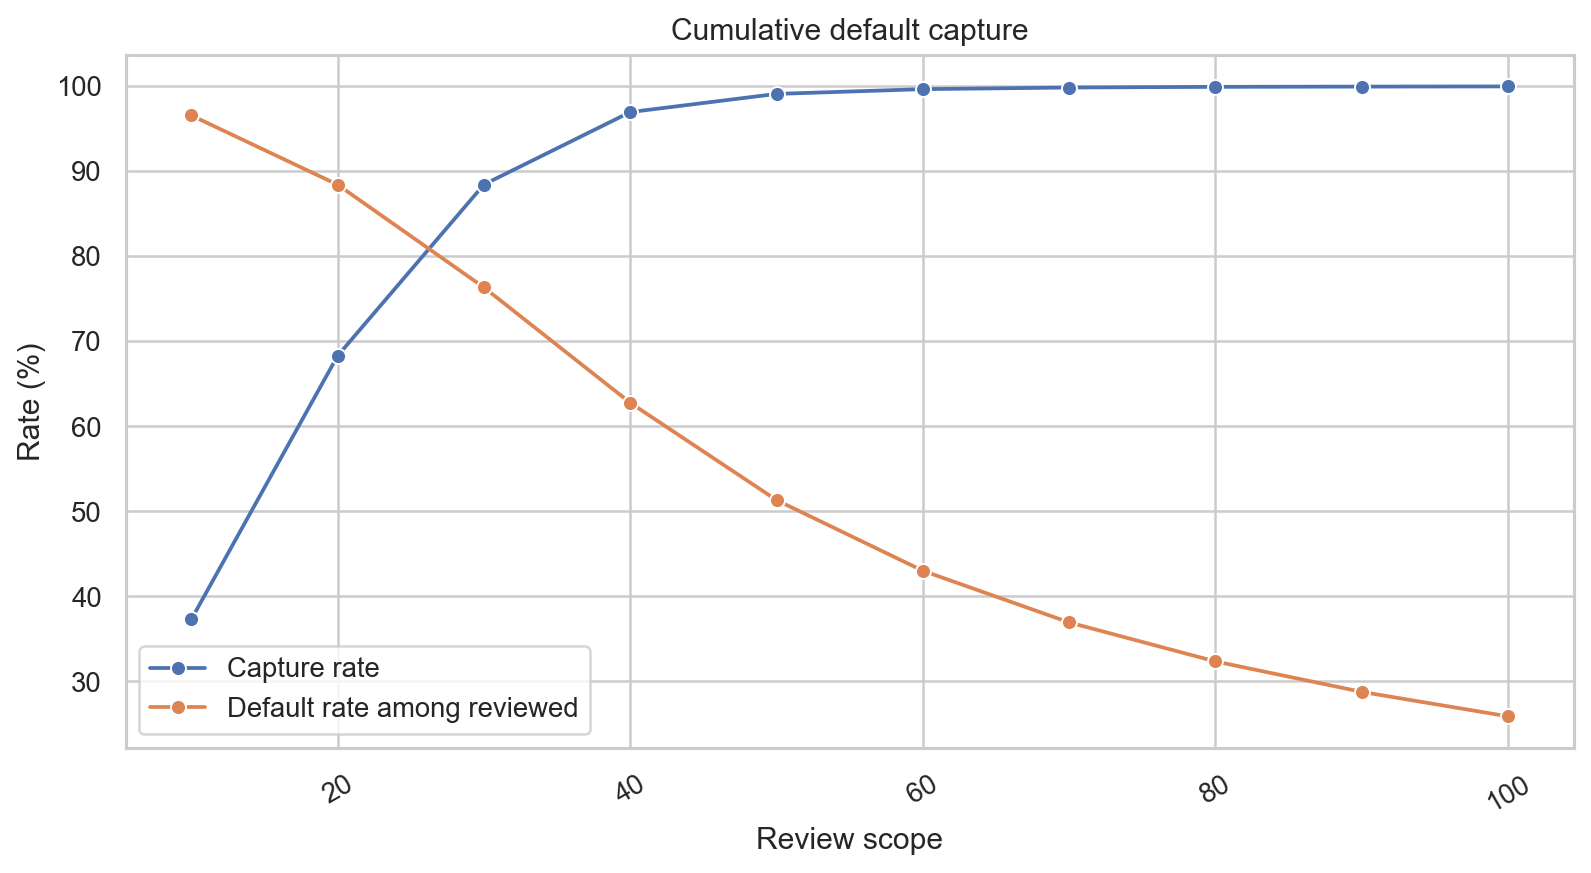

In [4]:
cumulative = load_table("top10_to_top100_cumulative_summary.csv")
cumulative["capture_rate_pct"] = pct(cumulative["capture_rate"])
cumulative["default_rate_among_reviewed_pct"] = pct(cumulative["default_rate_among_reviewed"])
display(cumulative)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=cumulative, x="review_scope", y="capture_rate_pct", marker="o", ax=ax, label="Capture rate")
sns.lineplot(data=cumulative, x="review_scope", y="default_rate_among_reviewed_pct", marker="o", ax=ax, label="Default rate among reviewed")
ax.set_title("Cumulative default capture")
ax.set_xlabel("Review scope")
ax.set_ylabel("Rate (%)")
ax.tick_params(axis="x", rotation=30)
ax.legend()
show_saved_figure("top10_to_top100_cumulative_summary.png")


review scope 확대는 capture 증가와 precision 하락을 동시에 만든다.
